### Runs on Cobalts only

In [20]:
# imports
# autoreload magic:
%load_ext autoreload
%autoreload 2
import glob
import copy
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from scipy.stats import norm
%matplotlib inline

from unifigs.figures import RatioPlot, SinglePlot

from NNMFit.utilities import load_pickle
from NNMFit.utilities import ScanHandler

from freefit_parameter_config import FreefitParamConfig

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load Bestfit Histograms (from do_scan_analysis.py)

In [2]:
# collect tha 2D fits for now:
step0_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20"
scan_names = ["nbestfit20_scan_astro_gamma_1D_10steps_round2"]

In [3]:
scan_names

['nbestfit20_scan_astro_gamma_1D_10steps_round2']

In [16]:
histogram_collection = {}
for scan_name in scan_names:
    print(scan_name)
    histogram_collection[scan_name] = {}

    data_hist_path = glob.glob(
        os.path.join(step0_path, scan_name, "Data_Histogram.pickle")
    )
    # check that its len = 1, then take the first element
    if len(data_hist_path) != 1:
        raise ValueError(
            f"Expected exactly one Data_Histogram.pickle for {scan_name}, found {len(data_hist_path)}"
        )
    data_hist_path = data_hist_path[0]
    histogram_collection[scan_name]["data"] = load_pickle(data_hist_path)

    mc_hist_path = glob.glob(
        os.path.join(step0_path, scan_name, "MC_Histogram*.pickle")
    )
    # check that its len >= 1, then take the first element
    if len(mc_hist_path) < 1:
        raise ValueError(
            f"Expected at least one MC_Histogram.pickle for {scan_name}, found {len(mc_hist_path)}"
        )
    mc_hist_path = mc_hist_path[0]
    histogram_collection[scan_name]["mc"] = load_pickle(mc_hist_path)

nbestfit20_scan_astro_gamma_1D_10steps_round2


Meta Information for binning and plotting

In [4]:
dimensions = {
    "IC86_pass2_SnowStorm_FTP_HESE_Cascades":
        {
            "reco_energy":
                {
                    "binning_key": "reco_energy",
                    "log_x": True,
                    "log_y": True,
                    "x_label": r"$E_{\mathrm{Truncated}}$ [GeV]",
                    "y_label": "Expected Rate [Hz]",
                    "sum_axes": 1,
                    "flip": False,
                    "ylims": [1e-11, 3e-4],
                },
            "reco_zenith":
                {
                    "binning_key": "reco_zenith",
                    "log_x": False,
                    "log_y": True,
                    "x_label": r"$\cos(\theta_{\mathrm{SplineMPE}})$",
                    "y_label": "Expected Rate [Hz]",
                    "sum_axes": 0,
                    "flip": True,
                    "ylims": None,
                },
        },
    "IC86_pass2_SnowStorm_FTP_HESE_Tracks":
        {
            "reco_energy":
                {
                    "binning_key": "reco_energy",
                    "log_x": True,
                    "log_y": True,
                    "x_label": r"$E_{\mathrm{Monopod}}$ [GeV]",
                    "y_label": "Expected Rate [Hz]",
                    "sum_axes": 1,
                    "flip": False,
                    "ylims": None,
                },
            "reco_zenith":
                {
                    "binning_key": "reco_zenith",
                    "log_x": False,
                    "log_y": True,
                    "x_label": r"$\cos(\theta_{\mathrm{Monopod}})$",
                    "y_label": "Expected Rate [Hz]",
                    "sum_axes": 0,
                    "flip": True,
                    "ylims": None,
                },
        },
}


In [17]:
binning_dict = {}

binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"] = {}
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_energy"] = np.geomspace(10**4.778, 10**7.1, 24)
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_zenith"] = np.linspace(-1, 1, 11)

binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Tracks"] = {}
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Tracks"]["reco_energy"] = np.geomspace(10**4.778, 10**7.1, 24)
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Tracks"]["reco_zenith"] = np.linspace(-1, 1, 11)

Plotting Functions

In [7]:
def get_histogram_projection(
    histogram,
    det_config,
    binning_dict,
    fit_dimension="2D",
    projected_dimension="energy",
    flip=False
):

    # fit_dimension is 2D (energy, zenith) or 3D (energy, zenith, ra)
    # sum_indices depend on fit_dimension
    if fit_dimension == "2D":
        sum_indices = {
            "reco_energy": 1,
            "reco_zenith": 0,
        }
        # reshape
        reshape_shape = (
            binning_dict[det_config]["reco_energy"].shape[0] - 1,
            binning_dict[det_config]["reco_zenith"].shape[0] - 1,
        )
        histogram = np.reshape(histogram, reshape_shape)

    elif fit_dimension == "3D":
        sum_indices = {
            "reco_energy": (1, 2),
            "reco_zenith": (0, 2),
            "reco_ra": (0, 1),
        }
        # reshape
        reshape_shape = (
            binning_dict[det_config]["reco_energy"].shape[0] - 1,
            binning_dict[det_config]["reco_zenith"].shape[0] - 1,
            binning_dict[det_config]["reco_ra"].shape[0] - 1,
        )
        histogram = np.reshape(histogram, reshape_shape)
    else:
        raise ValueError("fit_dimension must be '2D' or '3D'")

    # sum to collapse according to dimensions
    histogram = np.sum(histogram, axis=sum_indices[projected_dimension])

    # flip if necessary
    if flip:
        histogram = np.flip(histogram, axis=0)
    return histogram


def get_2D_histogram_projection(
    histogram,
    det_config,
    binning_dict,
    fit_dimension="2D",
    projected_dimension1="energy",
    projected_dimension2="zenith",
):
    # check that projected dimensions are either energy, zenith, or ra:
    if projected_dimension1 not in ["energy", "zenith", "ra"]:
        raise ValueError(
            f"projected_dimension1 must be 'energy', 'zenith', or 'ra', got {projected_dimension1}"
        )
    if projected_dimension2 not in ["energy", "zenith", "ra"]:
        raise ValueError(
            f"projected_dimension2 must be 'energy', 'zenith', or 'ra', got {projected_dimension2}"
        )
    # and they cannot be the same!
    if projected_dimension1 == projected_dimension2:
        raise ValueError(
            f"projected_dimension1 and projected_dimension2 must be different, got {projected_dimension1}"
        )

    projected_dimensions = set([projected_dimension1, projected_dimension2])
    # fit_dimension is 2D (energy, zenith) or 3D (energy, zenith, ra)
    # sum_indices depend on fit_dimension
    if fit_dimension == "2D":
        # reshape
        reshape_shape = (
            binning_dict[det_config]["reco_energy"].shape[0] - 1,
            binning_dict[det_config]["reco_zenith"].shape[0] - 1,
        )
        histogram = np.reshape(histogram, reshape_shape)

    elif fit_dimension == "3D":
        if set(["energy", "zenith"]) == projected_dimensions:
            # if we project onto energy and zenith, we need to sum over ra
            sum_index = 2
        elif set(["energy", "ra"]) == projected_dimensions:
            # if we project onto energy and ra, we need to sum over zenith
            sum_index = 1
        elif set(["zenith", "ra"]) == projected_dimensions:
            # if we project onto zenith and ra, we need to sum over energy
            sum_index = 0

        # reshape
        reshape_shape = (
            binning_dict[det_config]["reco_energy"].shape[0] - 1,
            binning_dict[det_config]["reco_zenith"].shape[0] - 1,
            binning_dict[det_config]["reco_ra"].shape[0] - 1,
        )
        histogram = np.reshape(histogram, reshape_shape)
        histogram = np.sum(histogram, axis=sum_index)
    else:
        raise ValueError("fit_dimension must be '2D' or '3D'")
    return histogram


In [8]:
def plot_histogram(
    ax,
    histogram_dict,
    det_config,
    plot_dimension,
    fit_dimension,
    binning_dict,
    draw_style="stairs",
    label="Label",
    color="black",
    **kwargs,
):

    # get the histogram
    histogram = get_histogram_projection(
        histogram_dict["histograms"][det_config],
        det_config,
        binning_dict,
        fit_dimension=fit_dimension,
        projected_dimension=plot_dimension,
        flip=dimensions[det_config][plot_dimension]["flip"]
    )
    # get fluctuations
    if "fluctuations" not in histogram_dict.keys() or \
        histogram_dict["fluctuations"] is None:
        fluctuations = np.sqrt(histogram)
    else:
        fluctuations = get_histogram_projection(
            np.sqrt(histogram_dict["fluctuations"][det_config]),
            det_config,
            binning_dict,
            fit_dimension=fit_dimension,
            projected_dimension=plot_dimension,
            flip=dimensions[det_config][plot_dimension]["flip"]
        )

    # draw the plot
    if draw_style == "stairs":
        ax.stairs(
            histogram,
            binning_dict[det_config][plot_dimension],
            label=label,
            color=color,
            **kwargs,
        )
    elif draw_style == "errors":
        bin_centers = np.diff(binning_dict[det_config][plot_dimension])/2 + \
            binning_dict[det_config][plot_dimension][:-1]
        ax.errorbar(
            bin_centers,
            histogram,
            yerr=fluctuations,
            fmt=".",
            label=label,
            color=color,
            **kwargs,
        )

In [9]:
def calc_ratio_err(numerator, denominator, err_numerator, err_denominator):
    """
    Calculate the error of the ratio of two histograms.
    """
    # numerator / denominator
    ratio = numerator / denominator
    # error propagation for division
    ratio_err = ratio * np.sqrt(
        (err_numerator / numerator)**2 + (err_denominator / denominator)**2
    )
    return ratio, ratio_err


def plot_ratio(
    ax,
    mc_dict,
    data_dict,
    det_config,
    plot_dimension,
    fit_dimension,
    binning_dict,
    include_mc_err=True,
    label="Ratio",
    color="black",
    capsize=2,
    markeredgecolor="black",
    **kwargs,
):

    # fit_dimension is 2D (energy, zenith) or 3D (energy, zenith, ra)
    # sum_indices depend on fit_dimension
    if fit_dimension == "2D":
        sum_indices = {
            "reco_energy": 1,
            "reco_zenith": 0,
        }
        # reshape
        reshape_shape = (
            binning_dict[det_config]["reco_energy"].shape[0] - 1,
            binning_dict[det_config]["reco_zenith"].shape[0] - 1,
        )
        mc_histogram = np.reshape(
            mc_dict["histograms"][det_config], reshape_shape
        )
        data_histogram = np.reshape(
            data_dict["histograms"][det_config], reshape_shape
        )
        if include_mc_err:
            mc_ssq = np.reshape(
                mc_dict["fluctuations"][det_config], reshape_shape
            )
    elif fit_dimension == "3D":
        sum_indices = {
            "reco_energy": (1, 2),
            "reco_zenith": (0, 2),
            "reco_ra": (0, 1),
        }
        # reshape
        reshape_shape = (
            binning_dict[det_config]["reco_energy"].shape[0] - 1,
            binning_dict[det_config]["reco_zenith"].shape[0] - 1,
            binning_dict[det_config]["reco_ra"].shape[0] - 1,
        )
        mc_histogram = np.reshape(
            mc_dict["histograms"][det_config], reshape_shape
        )
        data_histogram = np.reshape(
            data_dict["histograms"][det_config], reshape_shape
        )
        if include_mc_err:
            mc_ssq = np.reshape(
                mc_dict["fluctuations"][det_config], reshape_shape
            )
    else:
        raise ValueError("fit_dimension must be '2D' or '3D'")

    # reshape accordingly
    mc_histogram = np.sum(mc_histogram, axis=sum_indices[plot_dimension])
    data_histogram = np.sum(data_histogram, axis=sum_indices[plot_dimension])
    if include_mc_err:
        mc_ssq = np.sum(mc_ssq, axis=sum_indices[plot_dimension])

    # flip if necessary
    if dimensions[det_config][plot_dimension]["flip"]:
        mc_histogram = np.flip(mc_histogram, axis=0)
        data_histogram = np.flip(data_histogram, axis=0)
        if include_mc_err:
            mc_ssq = np.flip(mc_ssq, axis=0)

    ratio, ratio_err = calc_ratio_err(
        data_histogram, mc_histogram, np.sqrt(data_histogram),
        np.zeros_like(mc_histogram)
    )
    if include_mc_err:
        ratio, ratio_err = calc_ratio_err(
            data_histogram, mc_histogram, np.sqrt(data_histogram),
            np.sqrt(mc_ssq)
        )

    bin_centers = np.diff(binning_dict[det_config][plot_dimension])/2 + \
        binning_dict[det_config][plot_dimension][:-1]
    ax.errorbar(
        bin_centers,
        ratio,
        yerr=ratio_err,
        fmt=".",
        label=label,
        color=color,
        elinewidth=1,
        capsize=capsize,
        markeredgecolor=markeredgecolor,
        **kwargs,
    )


### Cascades Plots

In [12]:
%matplotlib inline

In [13]:
save_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/philipp/step_0_2"
os.system(f"mkdir -p {save_path}")

0

In [14]:
# mc_histogram = histogram_collection["background_tracks_only_2D"]["mc"]
# data_histogram = histogram_collection["background_tracks_only_2D"]["data"]

/tmp/ipykernel_361107/3165816160.py:9: RuntimeWarning: invalid value encountered in divide
  (err_numerator / numerator)**2 + (err_denominator / denominator)**2


Text(0.5, 0, '$\\cos(\\theta)$')

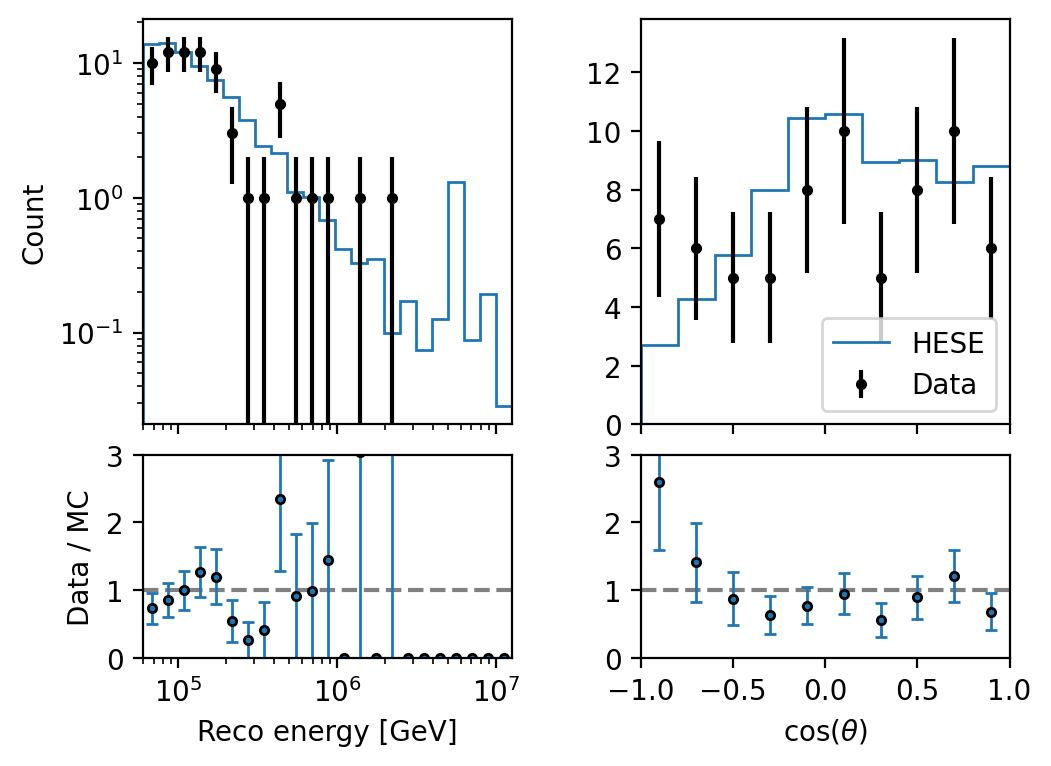

In [18]:
fig, axes = RatioPlot(pad=0.1, vert_pad=0.35).create(ncols=2, dpi=200)
det_config = "IC86_pass2_SnowStorm_FTP_HESE_Cascades"
scan_name = "nbestfit20_scan_astro_gamma_1D_10steps_round2"
label = "HESE"

# get matplotlib color prop cycle
color_cycle = plt.rcParams['axes.prop_cycle']
plot_data_points(
    axes,
    det_config,
    histogram_collection,
    scan_name,
    binning_dict=binning_dict,
    color="black",
    label="Data",
    # zorder=6,
)

plot_mc_and_ratio(
    axes,
    det_config,
    histogram_collection,
    scan_name,
    binning_dict=binning_dict,
    color=color_cycle.by_key()['color'][0],
    hist_label=label,
    ratio_label="",
    # include_mc_err=False,
)

axes[0][1].legend()

axes[0][0].set_xscale("log")
axes[0][0].set_yscale("log")
axes[0][0].set_ylabel("Count")
axes[0][0].set_xlim(
    np.min(binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_energy"]),
    np.max(binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_energy"])
)

axes[1][0].set_ylabel("Data / MC")
axes[1][0].set_ylim(0.0,3.0)
axes[1][0].set_xlabel("Reco energy [GeV]")
axes[1][0].axhline(1, color="grey", linestyle="--", zorder=-10)

axes[0][1].set_xlim(-1, 1.0)
axes[1][1].set_ylim(0.0,3.0)
axes[1][1].axhline(1, color="grey", linestyle="--", zorder=-10)
axes[1][1].set_xlabel(r"$\cos(\theta)$")

# # save for documentation
# plt.savefig(os.path.join(save_path, "Tracks_Bckgd_Data_MC.png"))

### Tracks Plots

/tmp/ipykernel_361107/3165816160.py:9: RuntimeWarning: invalid value encountered in divide
  (err_numerator / numerator)**2 + (err_denominator / denominator)**2


Text(0.5, 0, '$\\cos(\\theta)$')

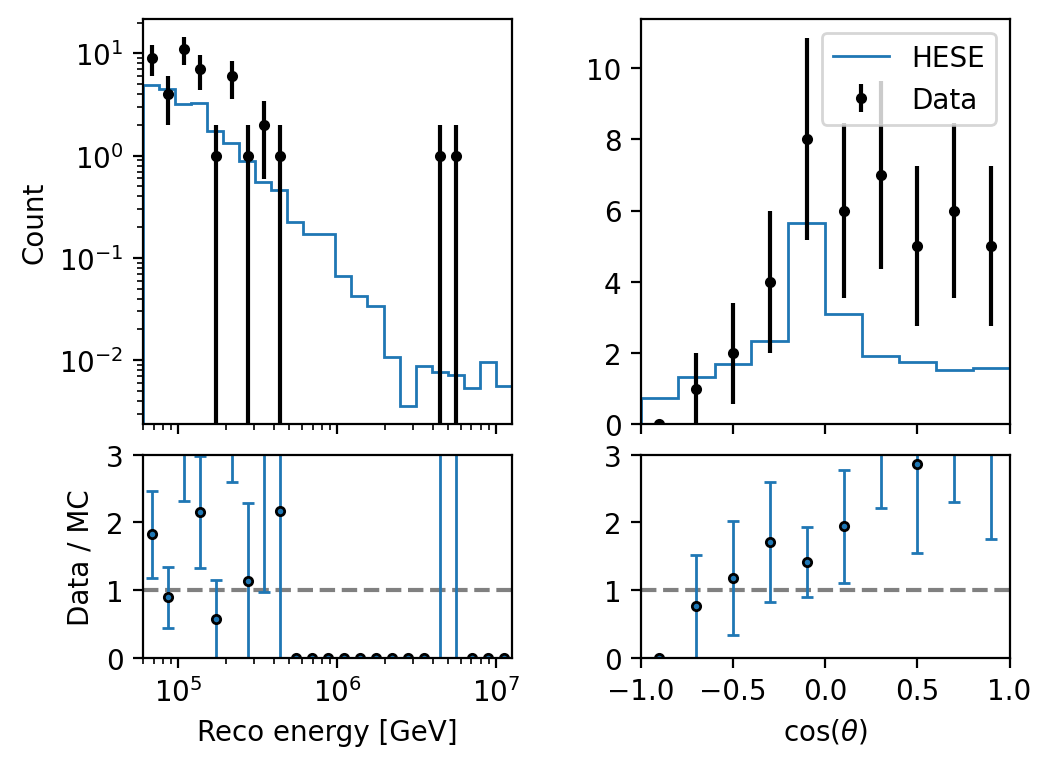

In [19]:
fig, axes = RatioPlot(pad=0.1, vert_pad=0.35).create(ncols=2, dpi=200)
det_config = "IC86_pass2_SnowStorm_FTP_HESE_Tracks"
scan_name = "nbestfit20_scan_astro_gamma_1D_10steps_round2"
label = "HESE"

# get matplotlib color prop cycle
color_cycle = plt.rcParams['axes.prop_cycle']
plot_data_points(
    axes,
    det_config,
    histogram_collection,
    scan_name,
    binning_dict=binning_dict,
    color="black",
    label="Data",
    # zorder=6,
)

plot_mc_and_ratio(
    axes,
    det_config,
    histogram_collection,
    scan_name,
    binning_dict=binning_dict,
    color=color_cycle.by_key()['color'][0],
    hist_label=label,
    ratio_label="",
    # include_mc_err=False,
)

axes[0][1].legend()

axes[0][0].set_xscale("log")
axes[0][0].set_yscale("log")
axes[0][0].set_ylabel("Count")
axes[0][0].set_xlim(
    np.min(binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_energy"]),
    np.max(binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_energy"])
)

axes[1][0].set_ylabel("Data / MC")
axes[1][0].set_ylim(0.0,3.0)
axes[1][0].set_xlabel("Reco energy [GeV]")
axes[1][0].axhline(1, color="grey", linestyle="--", zorder=-10)

axes[0][1].set_xlim(-1, 1.0)
axes[1][1].set_ylim(0.0,3.0)
axes[1][1].axhline(1, color="grey", linestyle="--", zorder=-10)
axes[1][1].set_xlabel(r"$\cos(\theta)$")

# # save for documentation
# plt.savefig(os.path.join(save_path, "Tracks_Bckgd_Data_MC.png"))